In [1]:
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

/lisc/data/scratch/menche/daniel/conda/envs/scnova/lib/python3.13/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


# Select data

In [149]:
adata = ad.read_h5ad('../heterogeneity/processed/rnaseq.samples.h5ad')
adata

AnnData object with n_obs × n_vars = 15081 × 61598
    obs: 'featurecounts_Percent_Assigned_', 'featurecounts_Percent_Duplicates', 'featurecounts_Percent_Assigned_O', 'featurecounts_Percent_Assigned_M', 'featurecounts_Percent_Assigned_MO', 'sra_study_acc', 'bio_project_acc', 'Tissue', 'Tissue_subtype', 'Disease', 'Disease_subtype', 'Treated', 'biotype_transcribed_unprocessed_pseudogene', 'biotype_unprocessed_pseudogene', 'biotype_miRNA', 'biotype_lncRNA', 'biotype_protein_coding', 'biotype_processed_pseudogene', 'biotype_snRNA', 'biotype_transcribed_processed_pseudogene', 'biotype_misc_RNA', 'biotype_TEC', 'biotype_transcribed_unitary_pseudogene', 'biotype_snoRNA', 'biotype_scaRNA', 'biotype_rRNA_pseudogene', 'biotype_unitary_pseudogene', 'biotype_polymorphic_pseudogene', 'biotype_pseudogene', 'biotype_rRNA', 'biotype_IG_V_pseudogene', 'biotype_scRNA', 'biotype_IG_V_gene', 'biotype_IG_C_gene', 'biotype_IG_J_gene', 'biotype_sRNA', 'biotype_ribozyme', 'biotype_translated_processed_pseudo

In [150]:
obs = adata.obs

In [157]:
def has_healthy_and_disease(x):
    return 'Healthy' in x.unique()

In [175]:
casecontrol = obs.groupby('sra_study_acc', observed = True).agg({'Disease': has_healthy_and_disease})
hasboth = casecontrol.loc[casecontrol.Disease, :].index.to_list()
hasboth_samples = obs.loc[obs.sra_study_acc.isin(hasboth), :]
multiple = hasboth_samples.groupby('Disease', observed = True).agg({'sra_study_acc': 'nunique'})
multiple.loc[multiple.sra_study_acc > 3, :]

,sra_study_acc
Disease,
Bladder cancer,4
Blood cancer,5
Brain cancer,5
Breast cancer,8
Cardiomyopathy,4
Colorectal cancer,21
Gastric cancer,6
Healthy,253
Inflammatory bowel disease,11


In [179]:
obs.query(
    'Tissue == "Skin" & Disease in ["Psoriasis", "Healthy"]'
).groupby(['sra_study_acc', 'Disease'], observed = True).count()

featurecounts_Percent_Assigned_  \
sra_study_acc Disease                                      
ERP022968     Healthy                                  4   
ERP110816     Healthy                                 29   
              Psoriasis                               30   
SRP026042     Healthy                                  5   
              Psoriasis                               16   
SRP035988     Healthy                                 82   
              Psoriasis                               92   
SRP043085     Healthy                                  8   
SRP065812     Healthy                                 16   
              Psoriasis                               36   
SRP078314     Healthy                                  7   
SRP151026     Healthy                                  1   
SRP215995     Healthy                                  8   
SRP229958     Healthy                                  4   
SRP238713     Healthy                                  9   
              Psoriasis                                6   
SRP245817     Healthy                                 12   

                         featurecounts_Percent_Duplicates  \
sra_study_acc Disease                                       
ERP022968     Healthy                                   4   
ERP110816     Healthy                                  29   
              Psoriasis                                30   
SRP026042     Healthy                                   5   
              Psoriasis                                16   
SRP035988     Healthy                                  82   
              Psoriasis                                92   
SRP043085     Healthy                                   8   
SRP065812     Healthy                                  16   
              Psoriasis                                36   
SRP078314     Healthy                                   7   
SRP151026     Healthy                                   1   
SRP215995     Healthy                                   8   
SRP229958     Healthy                                   4   
SRP238713     Healthy                                   9   
              Psoriasis                                 6   
SRP245817     Healthy                                  12   

                         featurecounts_Percent_Assigned_O  \
sra_study_acc Disease                                       
ERP022968     Healthy                                   4   
ERP110816     Healthy                                  29   
              Psoriasis                                30   
SRP026042     Healthy                                   5   
              Psoriasis                                16   
SRP035988     Healthy                                  82   
              Psoriasis                                92   
SRP043085     Healthy                                   8   
SRP065812     Healthy                                  16   
              Psoriasis                                36   
SRP078314     Healthy                                   7   
SRP151026     Healthy                                   1   
SRP215995     Healthy                                   8   
SRP229958     Healthy                                   4   
SRP238713     Healthy                                   9   
              Psoriasis                                 6   
SRP245817     Healthy                                  12   

                         featurecounts_Percent_Assigned_M  \
sra_study_acc Disease                                       
ERP022968     Healthy                                   4   
ERP110816     Healthy                                  29   
              Psoriasis                                30   
SRP026042     Healthy                                   5   
              Psoriasis                                16   
SRP035988     Healthy                                  82   
              Psoriasis                                92   
SRP043085     H

In [181]:
obs.loc[obs.sra_study_acc.isin(['SRP238713', 'SRP065812', 'SRP035988', 'SRP026042', 'ERP110816']), :].groupby(['sra_study_acc', 'Disease'], observed = True).count()

featurecounts_Percent_Assigned_  \
sra_study_acc Disease                                      
ERP110816     Healthy                                 29   
              Psoriasis                               30   
SRP026042     Healthy                                  5   
              Psoriasis                               16   
SRP035988     Healthy                                 82   
              Psoriasis                               92   
SRP065812     Healthy                                 16   
              Psoriasis                               36   
SRP238713     Healthy                                  9   
              Psoriasis                                6   

                         featurecounts_Percent_Duplicates  \
sra_study_acc Disease                                       
ERP110816     Healthy                                  29   
              Psoriasis                                30   
SRP026042     Healthy                                   5   
              Psoriasis                                16   
SRP035988     Healthy                                  82   
              Psoriasis                                92   
SRP065812     Healthy                                  16   
              Psoriasis                                36   
SRP238713     Healthy                                   9   
              Psoriasis                                 6   

                         featurecounts_Percent_Assigned_O  \
sra_study_acc Disease                                       
ERP110816     Healthy                                  29   
              Psoriasis                                30   
SRP026042     Healthy                                   5   
              Psoriasis                                16   
SRP035988     Healthy                                  82   
              Psoriasis                                92   
SRP065812     Healthy                                  16   
              Psoriasis                                36   
SRP238713     Healthy                                   9   
              Psoriasis                                 6   

                         featurecounts_Percent_Assigned_M  \
sra_study_acc Disease                                       
ERP110816     Healthy                                  29   
              Psoriasis                                30   
SRP026042     Healthy                                   5   
              Psoriasis                                16   
SRP035988     Healthy                                  82   
              Psoriasis                                92   
SRP065812     Healthy                                  16   
              Psoriasis                                36   
SRP238713     Healthy                                   9   
              Psoriasis                                 6   

                         featurecounts_Percent_Assigned_MO  bio_project_acc  \
sra_study_acc Disease                                                         
ERP110816     Healthy                                   29               29   
              Psoriasis                                 30               30   
SRP026042     Healthy                                    5                5   
              Psoriasis                                 16               16   
SRP035988     Healthy                                   82               82   
              Psoriasis                                 92               92   
SRP065812     Healthy                                   16               16   
              Psoriasis                                 36               36   
SRP238713     Healthy                                    9                9   
              Psoriasis                                  6                6   

                         Tissue  Tissue_subtype  Disease_subtype  Treated  \
sra_study_acc Disease                                                       
ER

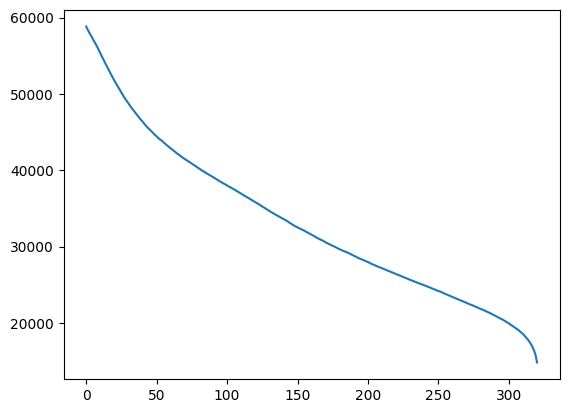

In [193]:
import matplotlib.pyplot as plt

data = adata[
    obs.sra_study_acc.isin(
        ['SRP238713', 'SRP065812', 'SRP035988', 'SRP026042', 'ERP110816']
    )
].to_df()

x = list(range(len(data)))
y = [((data > 0).sum(axis = 0) > i).sum() for i in x]
plt.plot(x, y)

In [211]:
filtered = data.loc[:, (data > 0).sum(axis = 0) > 300]
filtered.to_csv(
    'psoriasis/psoriasis.all.exp.tsv',
    sep = '\t'
)

In [202]:
meta = obs.loc[
    obs.sra_study_acc.isin(
        ['SRP238713', 'SRP065812', 'SRP035988', 'SRP026042', 'ERP110816']
    ),
    ['Disease', 'Tissue', 'sra_study_acc']
]
meta

,Disease,Tissue,sra_study_acc
SRX306070,Psoriasis,Skin,SRP026042
SRX306078,Psoriasis,Skin,SRP026042
SRX306090,Psoriasis,Skin,SRP026042
SRX306094,Psoriasis,Skin,SRP026042
SRX306082,Psoriasis,Skin,SRP026042
...,...,...,...
SRX7438916,Healthy,Skin,SRP238713
SRX7438928,Psoriasis,Skin,SRP238713
SRX7438926,Psoriasis,Skin,SRP238713
SRX7438925,Healthy,Skin,SRP238713


In [210]:
meta.to_csv(
    'psoriasis/psoriasis.all.meta.tsv',
    sep = '\t'
)

# Assess results

In [2]:
rcs = pd.read_csv(
    'psoriasis/psoriasis.all.exp.recombatseq.tsv',
    sep = '\t',
    index_col = 0
).T
rc = pd.read_csv(
    'psoriasis/psoriasis.all.exp.recombat.tsv',
    sep = '\t',
    index_col = 0
)
raw = pd.read_csv(
    'psoriasis/psoriasis.all.exp.tsv',
    sep = '\t',
    index_col = 0
)
meta = pd.read_csv(
    'psoriasis/psoriasis.all.meta.tsv',
    sep = '\t',
    index_col = 0
)

In [3]:
def compute_pca(data, counts):
    if counts:
        data = np.log1p(
            data.divide(data.sum(axis = 1), axis = 0) * 1e6
        )

    pca = PCA(n_components = 2)
    return pca.fit_transform(data)

raw
recombat
recombatseq


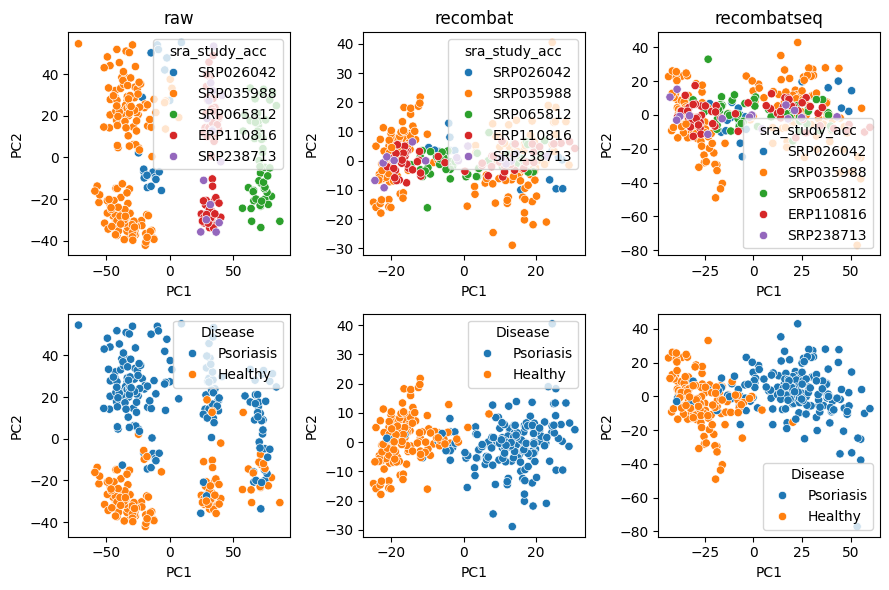

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt


fig, axs = plt.subplots(2, 3)
for i, (data, label, counts) in enumerate(
    zip(
        [raw, rc, rcs],
        ['raw', 'recombat', 'recombatseq'],
        [True, False, True]
    )
):
    print(label)
    df = pd.DataFrame(
        compute_pca(data, counts),
        index = data.index,
        columns = ['PC1', 'PC2']
    )
    df = df.merge(
        meta[['Disease', 'sra_study_acc']], 
        left_index = True,
        right_index = True,
        how = 'left'
    )
    sns.scatterplot(
        data = df,
        x = 'PC1',
        y = 'PC2',
        hue = 'sra_study_acc',
        ax = axs[0, i]
    )
    sns.scatterplot(
        data = df,
        x = 'PC1',
        y = 'PC2',
        hue = 'Disease',
        ax = axs[1, i]
    )
    axs[0, i].set_title(label)

fig.set_figwidth(9)
fig.set_figheight(6)
fig.tight_layout()
fig.savefig('datapcas.pdf')

all raw psoriasis/psoriasis.all.dea.tsv
all raw.shrink psoriasis/psoriasis.all.dea.lfcshrink.tsv
all recombat psoriasis/psoriasis.all.recombat.dea.tsv
all recombatseq psoriasis/psoriasis.all.recombatseq.dea.tsv
all recombatseq.shrink psoriasis/psoriasis.all.recombatseq.dea.lfcshrink.tsv
SRP238713 raw psoriasis/psoriasis.SRP238713.dea.tsv
SRP238713 raw.shrink psoriasis/psoriasis.SRP238713.dea.lfcshrink.tsv
SRP238713 recombat psoriasis/psoriasis.SRP238713.recombat.dea.tsv
SRP238713 recombatseq psoriasis/psoriasis.SRP238713.recombatseq.dea.tsv
SRP238713 recombatseq.shrink psoriasis/psoriasis.SRP238713.recombatseq.dea.lfcshrink.tsv
SRP065812 raw psoriasis/psoriasis.SRP065812.dea.tsv
SRP065812 raw.shrink psoriasis/psoriasis.SRP065812.dea.lfcshrink.tsv
SRP065812 recombat psoriasis/psoriasis.SRP065812.recombat.dea.tsv
SRP065812 recombatseq psoriasis/psoriasis.SRP065812.recombatseq.dea.tsv
SRP065812 recombatseq.shrink psoriasis/psoriasis.SRP065812.recombatseq.dea.lfcshrink.tsv
SRP035988 raw ps

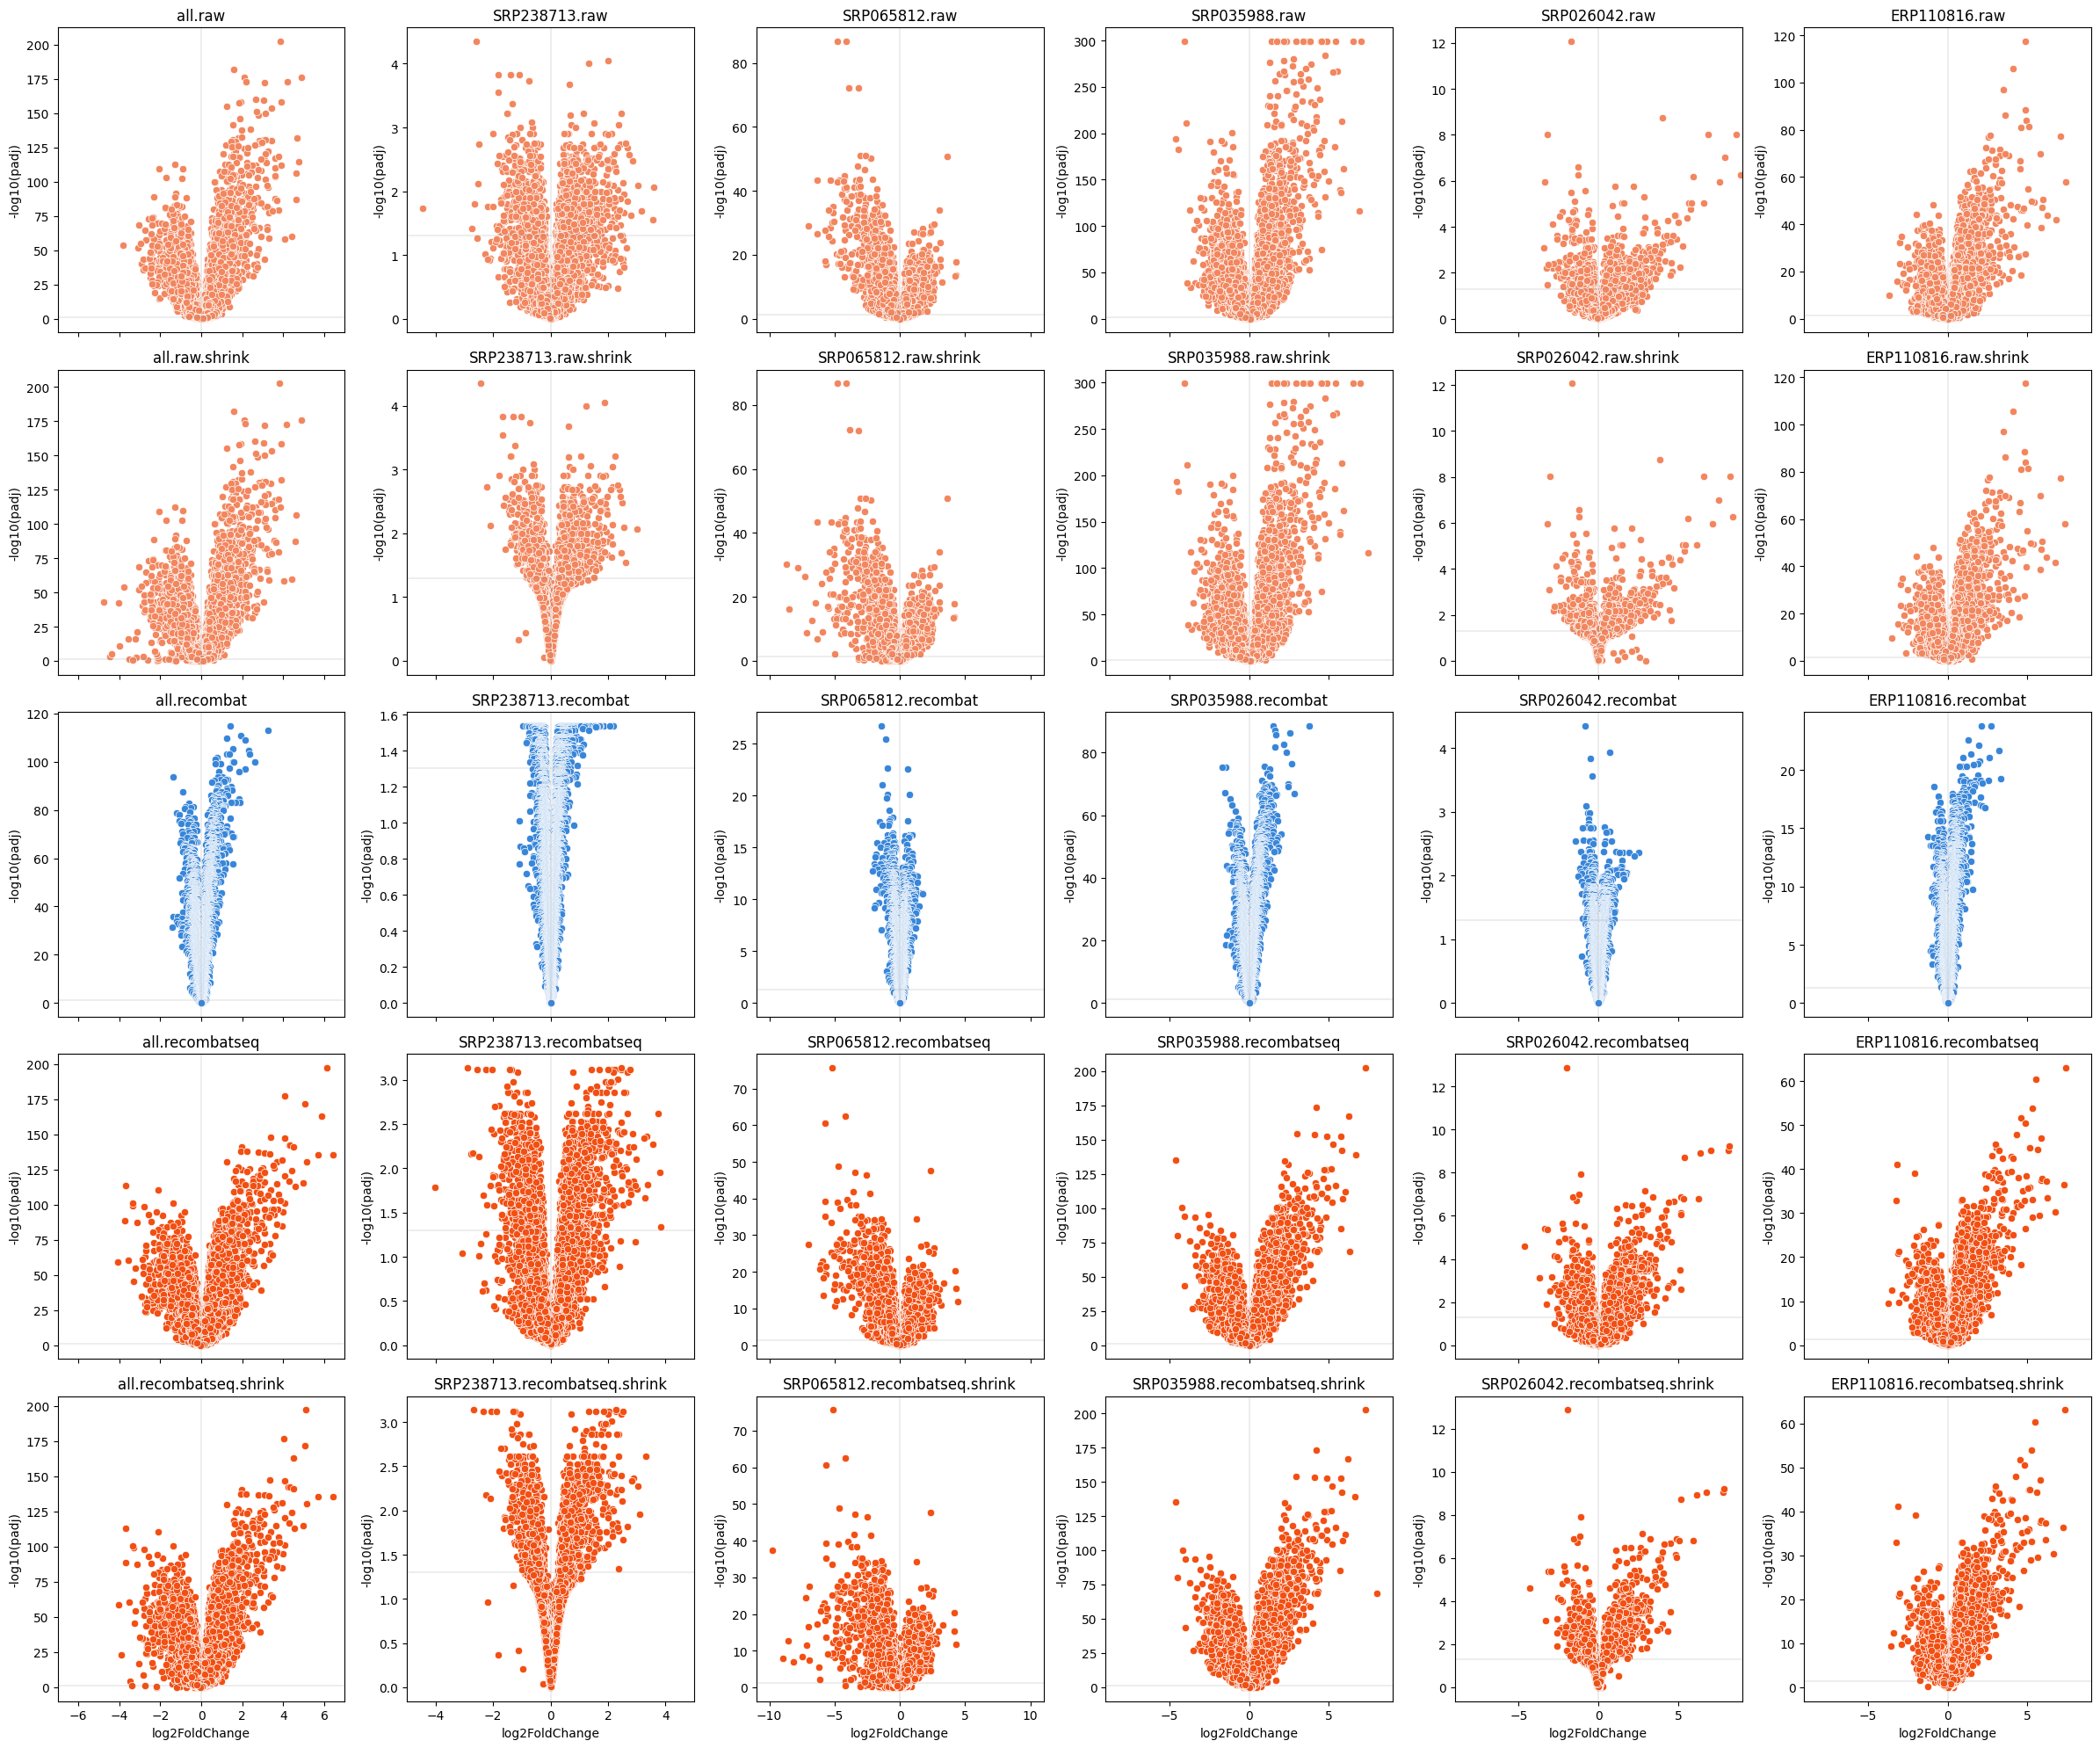

In [23]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

padj_t = 0.05
dea_results, degs = {}, {}
accessions = ['SRP238713', 'SRP065812', 'SRP035988', 'SRP026042', 'ERP110816']
keys = ['all', *accessions]
xlims = [[-7, 7], [-5, 5], [-11, 11], [-9, 9], [-9, 9], [-9, 9]]
fig, axs = plt.subplots(5, len(keys), sharex = 'col')
topbottom = 300
for axcol, key, xlim in zip(axs.T, keys, xlims):
    for ax, c, version in zip(
        axcol, 
        ['#F2865E', '#F2865E', '#3886D9', '#F24F13', '#F24F13'], 
        ['raw', 'raw.shrink', 'recombat', 'recombatseq', 'recombatseq.shrink']
    ):
        if version == 'raw':
            filename = f'psoriasis/psoriasis.{key}.dea.tsv' 

        elif version.endswith('shrink'):
            filename = (
                f'psoriasis/psoriasis.{key}.dea.lfcshrink.tsv'
                if version.startswith('raw')
                else f'psoriasis/psoriasis.{key}.recombatseq.dea.lfcshrink.tsv'
            )
            
        else:
            filename = f'psoriasis/psoriasis.{key}.{version}.dea.tsv'   
            
        print(key, version, filename)
        df = pd.read_csv(
            filename,
            sep = '\t',
            index_col = 0
        )

        if version == 'recombat':
            df.rename(
                columns = {
                    'adj.P.Val': 'padj',
                    'logFC': 'log2FoldChange'
                },
                inplace = True
            )
        k = f'{key}_{version}'
        dea_results[k] = df
        degs[k] = pd.concat(
            [
                df.query('padj < @padj_t & log2FoldChange < 0').log2FoldChange.abs().nlargest(topbottom),
                df.query('padj < @padj_t & log2FoldChange > 0').log2FoldChange.abs().nlargest(topbottom)
            ]
        )

        df = df.copy()
        df.loc[df.padj == 0, 'padj'] = df.loc[df.padj != 0, 'padj'].min()
        df['-log10(padj)'] = -np.log10(df.padj)
        ndiff = (df.padj < padj_t).sum()
        sns.scatterplot(
            data = df,
            x = 'log2FoldChange',
            y = '-log10(padj)',
            ax = ax,
            c = c
        )
        
        ax.axvline(0, lw = 0.2, c = 'grey')
        ax.axhline(-np.log10(padj_t), lw = 0.2, c = 'grey')
        ax.set_xlim(*xlim)
        # ax.set_ylim(-2, 100)
        ax.set_title('.'.join([key, version]))

fig.set_figwidth(len(keys) * 4)
fig.set_figheight(20)
fig.tight_layout()
fig.savefig('diffexpcomp.png', dpi = 300)

In [116]:
from functools import reduce

study_degs = {
    k: degs[f'{k}_raw.shrink'].index.to_list()
    for k
    in accessions
}
degunion = reduce(lambda x, y: set(x) | set(y), study_degs.values())
len(degunion)

1863

In [121]:
def get_topbottom_n(df, topbottom, padj_t):
    res = pd.concat(
        [
            df.query('padj < @padj_t & log2FoldChange < 0').log2FoldChange.abs().nlargest(topbottom),
            df.query('padj < @padj_t & log2FoldChange > 0').log2FoldChange.abs().nlargest(topbottom)
        ]
    )
    return res

rc_degs = set(get_topbottom_n(dea_results['all_recombat'], 932, 0.05).index)
rcs_degs = set(get_topbottom_n(dea_results['all_recombatseq'], 932, 0.05).index)
numbers = [len(degunion), len(rc_degs & degunion), len(rcs_degs & degunion)]
numbers, [i/len(degunion) for i in numbers]

([1863, 1009, 1122], [1.0, 0.5415995705850778, 0.6022544283413849])

In [117]:
from functools import reduce

rc_degs = set(degs['all_recombat'].index.to_list())
rcs_degs = set(degs['all_recombatseq'].index.to_list())
genes = pd.DataFrame()
for k, s in study_degs.items():
    df = pd.DataFrame(index = s)
    df[k] = True
    if genes.empty:
        genes = df
        continue

    genes = genes.merge(df, left_index = True, right_index = True, how = 'outer')


genes = genes.fillna(False)
quasi_intersect = set(genes[genes.sum(axis = 1) > 2].index)
numbers = [len(quasi_intersect), len(rc_degs & quasi_intersect), len(rcs_degs & quasi_intersect)]
numbers, [i/len(quasi_intersect) for i in numbers]

/tmp/ipykernel_1985787/3297346785.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  genes = genes.fillna(False)


([309, 262, 296], [1.0, 0.8478964401294499, 0.9579288025889967])

In [63]:
for acc in accessions:
    rcdf = dea_results[f'{acc}_recombat']
    rcsdf = dea_results[f'{acc}_recombatseq']
    rawdf = dea_results[f'{acc}_raw.shrink']
    mdf = rcsdf.merge(
        rcdf,
        left_index = True,
        right_index = True,
        how = 'left',
        suffixes = ['_rcs', '_rc']
    )
    factors = mdf.log2FoldChange_rc.abs() / mdf.log2FoldChange_rcs.abs()
    print(acc, factors.mean(), factors.median())

SRP238713 1.5475307010763764 0.3572964902564451
SRP065812 0.9817151851950279 0.3441096222762085
SRP035988 0.8014025635055575 0.38280907241095247
SRP026042 0.7932959792475248 0.35698981617508
ERP110816 0.8009360712021008 0.3563929599689129


In [80]:
import itertools as it

def get_degs(df, lfc, alpha, topbottom = 300):
    degs = pd.concat(
        [
            df.query('padj < @alpha & log2FoldChange < @lfc').log2FoldChange.nlargest(topbottom),
            df.query('padj < @alpha & log2FoldChange > @lfc').log2FoldChange.nsmallest(topbottom)
        ]
    )
    
    return set(degs.index)

    
comparisons = []
for sigp, siglfc in it.product([0.1, 0.05, 0.01], [0.25, 0.5, 1]):
    for acc in accessions:
        rcdf = dea_results[f'{acc}_recombat']
        rcsdf = dea_results[f'{acc}_recombatseq']
        rawdf = dea_results[f'{acc}_raw.shrink']

        rcdegs = get_degs(rcdf, siglfc/3, sigp, 300)
        rcsdegs = get_degs(rcsdf, siglfc, sigp, 300)
        rawdegs = get_degs(rawdf, siglfc, sigp, 300)
        # comparisons.append(
        #     [
        #         acc, 
        #         len(rcdegs & rawdegs) / len(rawdegs),
        #         len(rcsdegs & rawdegs) / len(rawdegs),
        #         sigp, siglfc
        #     ]
        # )
        comparisons.append(
            [
                acc, 
                len(rcsdegs & rawdegs) / len(rawdegs),
                sigp, siglfc, 'recombatseq'
            ]
        )
        comparisons.append(
            [
                acc, 
                len(rcdegs & rawdegs) / len(rawdegs),
                sigp, siglfc, 'recombat'
            ]
        )

comparisons = pd.DataFrame(
    comparisons,
    columns = ['accession', 'recall', 'sigp', 'siglfc', 'method']
)
comparisons

,accession,recall,sigp,siglfc,method
0,SRP238713,0.395000,0.10,0.25,recombatseq
1,SRP238713,0.090000,0.10,0.25,recombat
2,SRP065812,0.465000,0.10,0.25,recombatseq
3,SRP065812,0.045000,0.10,0.25,recombat
4,SRP035988,0.705000,0.10,0.25,recombatseq
...,...,...,...,...,...
85,SRP035988,0.483333,0.01,1.00,recombat
86,SRP026042,0.467172,0.01,1.00,recombatseq
87,SRP026042,0.209596,0.01,1.00,recombat
88,ERP110816,0.816667,0.01,1.00,recombatseq


In [81]:
comp_data = comparisons.iloc[:, 1:]
comp_data['cutoffs'] = comp_data.apply(
    lambda x: f'p = {x['sigp']:.2f}; lfc = {x['siglfc']:.2f}',
    axis = 1
)
comp_data

,recall,sigp,siglfc,method,cutoffs
0,0.395000,0.10,0.25,recombatseq,p = 0.10; lfc = 0.25
1,0.090000,0.10,0.25,recombat,p = 0.10; lfc = 0.25
2,0.465000,0.10,0.25,recombatseq,p = 0.10; lfc = 0.25
3,0.045000,0.10,0.25,recombat,p = 0.10; lfc = 0.25
4,0.705000,0.10,0.25,recombatseq,p = 0.10; lfc = 0.25
...,...,...,...,...,...
85,0.483333,0.01,1.00,recombat,p = 0.01; lfc = 1.00
86,0.467172,0.01,1.00,recombatseq,p = 0.01; lfc = 1.00
87,0.209596,0.01,1.00,recombat,p = 0.01; lfc = 1.00
88,0.816667,0.01,1.00,recombatseq,p = 0.01; lfc = 1.00


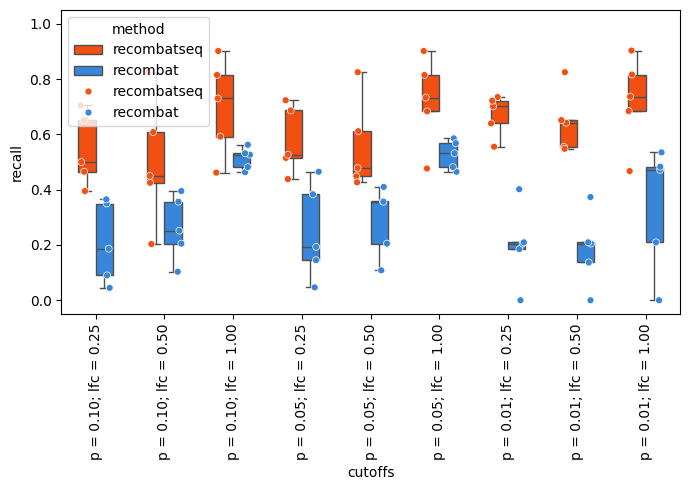

In [109]:
fig, ax = plt.subplots()

sns.boxplot(
    data = comp_data,
    x = 'cutoffs',
    y = 'recall',
    hue = 'method',
    palette = {'recombat': '#3886D9', 'recombatseq': '#F24F13'},
    showfliers = False,
    saturation = 1,
    width = 0.5,
    ax = ax
)
sns.stripplot(
    data = comp_data,
    x = 'cutoffs',
    y = 'recall',
    hue = 'method',
    palette = {'recombat': '#3886D9', 'recombatseq': '#F24F13'},
    dodge = True,
    linewidth = 0.5,
    edgecolor = 'white',
    ax = ax
)
ax.set_ylim(-0.05, 1.05)
ax.tick_params(axis='x', labelrotation=90)
fig.set_figwidth(7)
fig.set_figheight(5)
fig.tight_layout()
fig.savefig('individual_recalls.pdf')